# 🔬 Fintech Churn Engine: Multi-Model Evaluation & Visualization
This workbench ingests raw sequential transactional lines, tests alternative machine learning classifiers (XGBoost vs Random Forest), and visualizes threshold metrics.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve

In [2]:
csv_path = 'fintech_transactions.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError('Dataset missing! Ensure download_dataset.py ran successfully.')

df = pd.read_csv(csv_path)
features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig']
X = df[features]
y = (((df['oldbalanceOrg'] - df['newbalanceOrig']) > 15000) | (df['step'] > 48)).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Ingested shapes - Train: {X_train.shape}, Evaluation: {X_test.shape}')

Ingested shapes - Train: (16, 4), Evaluation: (4, 4)



=== XGBoost Performance Profile (Threshold = 0.70) ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


=== RandomForest Performance Profile (Threshold = 0.70) ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



/home/orajava/Documents/Projects/Python/fintech-churn-service/.env/lib64/python3.12/site-packages/sklearn/metrics/_ranking.py:1174: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/home/orajava/Documents/Projects/Python/fintech-churn-service/.env/lib64/python3.12/site-packages/sklearn/metrics/_ranking.py:1174: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


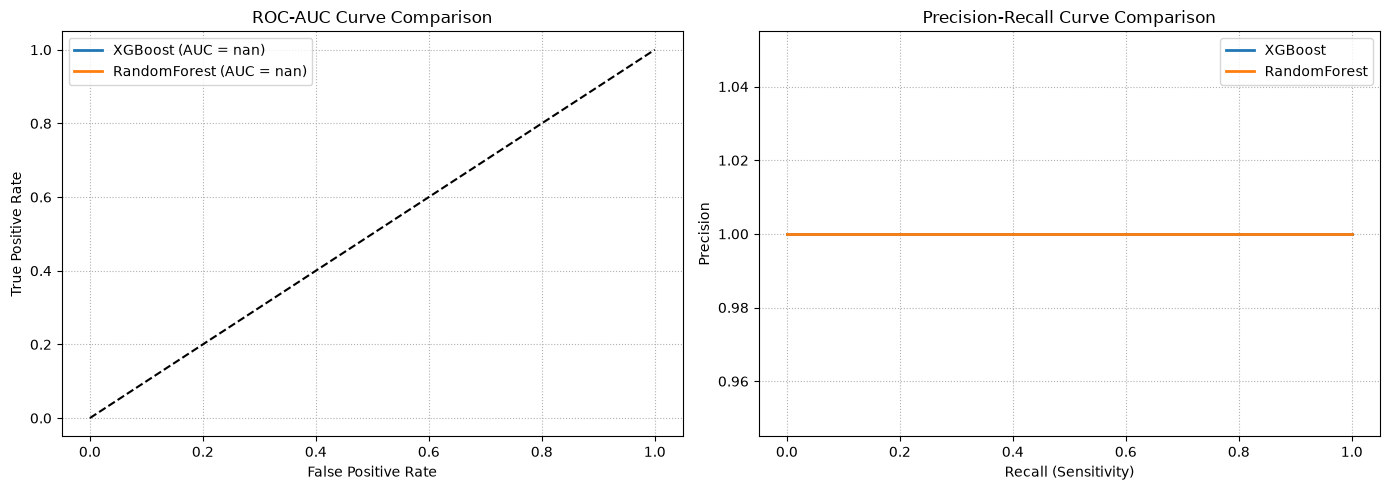


✅ Success! XGBoost exported to artifacts directory for FastAPI usage.


In [3]:
models = {
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='logloss'),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
}

results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    probs = clf.predict_proba(X_test)[:, 1]
    results[name] = probs
    
    preds = (probs >= 0.70).astype(int)
    print(f'\n=== {name} Performance Profile (Threshold = 0.70) ===')
    print(classification_report(y_test, preds, zero_division=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for name, probs in results.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})', lw=2)
ax1.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax1.set_title('ROC-AUC Curve Comparison')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, linestyle=':')

for name, probs in results.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ax2.plot(recall, precision, label=name, lw=2)
ax2.set_title('Precision-Recall Curve Comparison')
ax2.set_xlabel('Recall (Sensitivity)')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

if not os.path.exists('../app/artifacts'):
    os.makedirs("../app/artifacts", exist_ok=True)

with open('../app/artifacts/churn_model.pkl', 'wb') as f:
    pickle.dump(models['XGBoost'], f)
print('\n✅ Success! XGBoost exported to artifacts directory for FastAPI usage.')